# Ordinal Regression



[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/notebooks/02_categorical_regression.ipynb)

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

In [3]:
# Get utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

from utils import value_counts, decorate

<IPython.core.display.Javascript object>

In [5]:
# Make the figures smaller to save some screen real estate

plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

<IPython.core.display.Javascript object>

## Data

In [24]:
# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_3a.ipynb

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_4.hdf"
download(DATA_PATH + filename)

<IPython.core.display.Javascript object>

In [25]:
gss = pd.read_hdf(filename, "gss")
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'clmtcaus', 'clmtusa', 'clmtwrld',
       'cohort', 'commun', 'conarmy', 'conbus', 'conclerg', 'coneduc',
       'confed', 'confinan', 'coninc', 'conjudge', 'conlabor', 'conlegis',
       'conmedic', 'conpress', 'conrinc', 'consci', 'contv', 'degree', 'educ',
       'eqwlth', 'fair', 'fear', 'fund', 'goodlife', 'hapmar', 'happy',
       'health', 'helpful', 'id', 'life', 'partyid', 'polviews', 'pres16',
       'pres20', 'race', 'realinc', 'realrinc', 'reg16', 'region', 'relig',
       'relig16', 'reliten', 'res16', 'rincome', 'satfin', 'satjob', 'sex',
       'sexbirth', 'sexnow', 'srcbelt', 'trust', 'wtssall', 'year'],
      dtype='object')

<IPython.core.display.Javascript object>

> Taken all together, how would you say things are these days--would you say that you are very happy, pretty happy, or not too happy?

```
1 Very happy
2 Pretty happy
3 Not too happy
```

In [26]:
value_counts(gss["happy"])

,counts
values,
1.0,21550
2.0,37446
3.0,8681
NaN,4713


<IPython.core.display.Javascript object>

In [267]:
gss["y"] = gss["happy"].replace({3: 0, 2: 1, 1: 2})
value_counts(gss["y"], normalize=True) * 100

,counts
values,
0.0,11.991988
1.0,51.728139
2.0,29.769305
NaN,6.510568


<IPython.core.display.Javascript object>

In [268]:
happy_map = {
    2: "Very happy",
    1: "Pretty happy",
    0: "Not too happy",
}

<IPython.core.display.Javascript object>

In [269]:
from utils import round_into_bins

gss["age_group"] = round_into_bins(gss["age"], 5, low=13) + 2

<IPython.core.display.Javascript object>

In [270]:
age_table = (
    pd.crosstab(gss["age_group"], gss["y"], normalize="index").rename(columns=happy_map)
    * 100
)
age_table

y,Not too happy,Pretty happy,Very happy
age_group,,,
20.0,14.754098,60.232681,25.013221
25.0,13.913290,57.778407,28.308303
30.0,11.215502,57.706988,31.077510
35.0,11.491515,55.894611,32.613873
40.0,12.492298,55.653112,31.854590
45.0,12.417871,56.964520,30.617608
50.0,12.726350,54.543916,32.729734
55.0,14.437804,53.119163,32.443033
60.0,12.406736,54.103603,33.489661


<IPython.core.display.Javascript object>

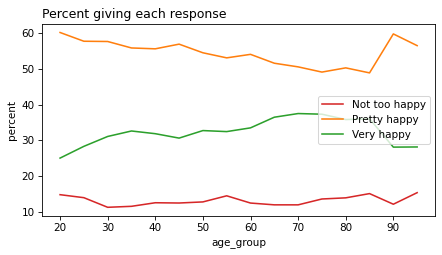

<IPython.core.display.Javascript object>

In [275]:
colors = ["C3", "C1", "C2"]
age_table.plot(color=colors)
decorate(ylabel="percent", title="Percent giving each response")

In [276]:
gss["cohort"] = gss["cohort"].replace(9999, np.nan)

<IPython.core.display.Javascript object>

In [277]:
gss["birth_group"] = round_into_bins(gss["cohort"], 5, low=1903) + 2
gss.groupby("birth_group")["cohort"].describe()

,count,mean,std,min,25%,50%,75%,max
birth_group,,,,,,,,
1905.0,830.0,1905.213253,1.430857,1903.0,1904.0,1905.0,1907.0,1907.0
1910.0,1275.0,1910.114510,1.452892,1908.0,1909.0,1910.0,1911.5,1912.0
1915.0,1909.0,1915.102148,1.422174,1913.0,1914.0,1915.0,1916.0,1917.0
1920.0,2522.0,1920.087629,1.429506,1918.0,1919.0,1920.0,1921.0,1922.0
1925.0,3102.0,1925.071889,1.431998,1923.0,1924.0,1925.0,1926.0,1927.0
1930.0,3102.0,1930.059961,1.403783,1928.0,1929.0,1930.0,1931.0,1932.0
1935.0,3566.0,1935.065059,1.375492,1933.0,1934.0,1935.0,1936.0,1937.0
1940.0,4343.0,1940.103155,1.433124,1938.0,1939.0,1940.0,1941.0,1942.0
1945.0,5656.0,1945.124470,1.449801,1943.0,1944.0,1945.0,1946.0,1947.0


<IPython.core.display.Javascript object>

In [278]:
cohort_table = (
    pd.crosstab(gss["birth_group"], gss["y"], normalize="index").rename(
        columns=happy_map
    )
    * 100
)

<IPython.core.display.Javascript object>

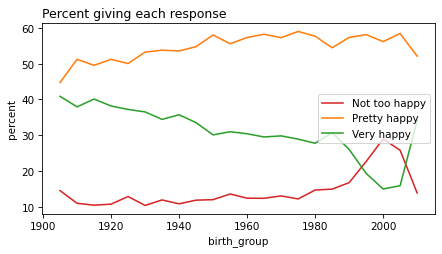

<IPython.core.display.Javascript object>

In [279]:
cohort_table.plot(color=colors)
decorate(ylabel="percent", title="Percent giving each response")

## Ordinal Regression

In [175]:
data = gss.dropna(subset=["y", "age"])
data.shape

(66959, 63)

<IPython.core.display.Javascript object>

In [176]:
data = data.sample(5000)

<IPython.core.display.Javascript object>

In [178]:
y = data["y"].values
age = data["age"].values

# Center age
age_shift = age.mean()
age_centered = age - age_shift

<IPython.core.display.Javascript object>

In [179]:
from scipy.special import logit

cutpoint_0 = logit(0.12)  # Cutpoint between "Not too happy" and "Pretty happy"
cutpoint_1 = logit(0.64)  # Cutpoint between "Pretty happy" and "Very happy"

print(cutpoint_0, cutpoint_1)

-1.9924301646902063 0.5753641449035619


<IPython.core.display.Javascript object>

In [180]:
with pm.Model() as ordinal_model:
    # Priors for the cutpoints (thresholds) between categories
    cutpoints = pm.Normal(
        "cutpoints",
        mu=np.array([-2, 0.6]),
        sigma=0.5,
        shape=2,
        transform=pm.distributions.transforms.ordered,
    )

    # Age slope
    beta_age = pm.Normal("beta_age", 0, 0.1)

    # Compute cumulative logits
    eta = beta_age * age_centered

    # Hide the details of the calculation
    y_obs = pm.OrderedLogistic(
        "y_obs", eta=eta, cutpoints=cutpoints, compute_p=False, observed=y
    )

<IPython.core.display.Javascript object>

In [181]:
with pm.Model() as ordinal_model:
    # Priors for the cutpoints (thresholds) between categories
    cutpoints = pm.Normal(
        "cutpoints",
        mu=np.array([-2, 0.6]),
        sigma=0.5,
        shape=2,
        transform=pm.distributions.transforms.ordered,
    )

    # Age slope
    beta_age = pm.Normal("beta_age", 0, 0.1)

    # Linear predictor for each respondent (this is just age effect)
    eta = beta_age * age_centered  # shape (n,)

    # Compute cumulative logits for each observation and each cutpoint
    logits = cutpoints - eta[:, None]  # shape (n, 2)

    # Convert logits to cumulative probabilities
    cdf_0 = pm.math.sigmoid(logits[:, 0])  # P(y ≤ 0)
    cdf_1 = pm.math.sigmoid(logits[:, 1])  # P(y ≤ 1)

    # Convert cumulative probabilities to category probabilities
    p0 = cdf_0
    p1 = cdf_1 - cdf_0
    p2 = 1 - cdf_1

    # Stack into final probability matrix
    p = pm.math.stack([p0, p1, p2], axis=1)

    # Likelihood using explicit p
    y_obs = pm.Categorical("y_obs", p=p, observed=y)

<IPython.core.display.Javascript object>

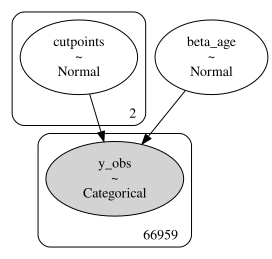

<IPython.core.display.Javascript object>

In [182]:
az.model_to_graphviz(ordinal_model)

In [183]:
with ordinal_model:
    idata = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta_age]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 167 seconds.


<IPython.core.display.Javascript object>

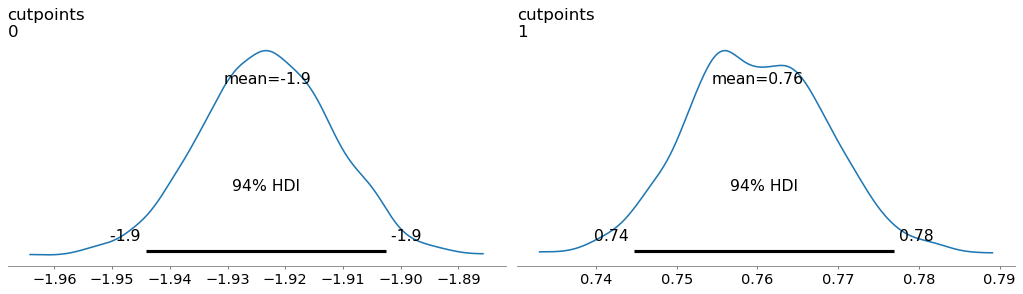

<IPython.core.display.Javascript object>

In [192]:
az.plot_posterior(idata, var_names=["cutpoints"])
decorate()

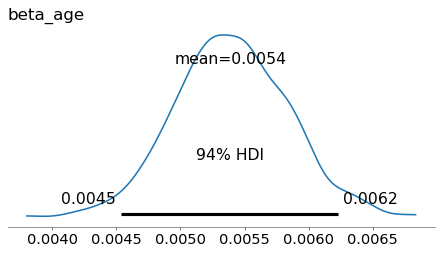

<IPython.core.display.Javascript object>

In [193]:
az.plot_posterior(idata, var_names=["beta_age"])
decorate()

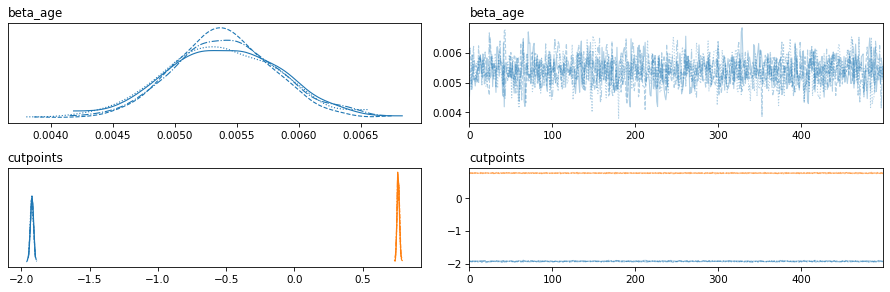

<IPython.core.display.Javascript object>

In [194]:
az.plot_trace(idata)
decorate()

To check these properties numerically, we can look at two key summary statistics: ESS and r-hat.

*    Effective Sample Size (ESS) tells us how much independent information the chains actually contribute. If successive values within a chain are highly correlated, the chain isn’t exploring the posterior efficiently, and ESS will be smaller than the total number of draws.

*    r-hat quantifies the difference between chains. If all chains converged to the same posterior distribution, r-hat should be close to 1. If the chains are exploring different regions, r-hat will be larger than 1, indicating failure to coverge.

In [195]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_age,0.005,0.000,0.005,0.006,0.0,0.0,1344.0,1402.0,1.01
cutpoints[0],-1.923,0.011,-1.944,-1.902,0.0,0.0,1228.0,1121.0,1.00
cutpoints[1],0.760,0.009,0.745,0.777,0.0,0.0,2743.0,1465.0,1.00


<IPython.core.display.Javascript object>

### Interpreting the results

In [196]:
def get_sample(idata, var_name):
    """Extract a posterior sample from idata

    idata: InferenceData object
    var_name: string

    returns: NumPy array
    """
    return idata.posterior[var_name].stack(sample=["chain", "draw"])

<IPython.core.display.Javascript object>

In [197]:
# Center the age range
age_range = np.arange(18, 95)
age_range_centered = age_range - age_shift
n_ages = len(age_range)

<IPython.core.display.Javascript object>

In [285]:
from scipy.special import expit

cutpoints = get_sample(idata, "cutpoints").values  # shape (2, n_samples)
beta_age = get_sample(idata, "beta_age").values  # shape (n_samples,)

n_samples = beta_age.shape[0]
n_ages = len(age_range)

# Predicted probabilities: shape (n_samples, n_ages, 3)
predicted_probs = np.zeros((n_samples, n_ages, 3))

for i in range(n_samples):
    cp0, cp1 = cutpoints[:, i]
    slope = beta_age[i]

    eta = (
        np.array([cp0, cp1]) - slope * age_range_centered[:, None]
    )  # shape (n_ages, 2)

    # Convert to cumulative probabilities
    cdf_0 = expit(eta[:, 0])
    cdf_1 = expit(eta[:, 1])

    # Convert to category probabilities
    p0 = cdf_0
    p1 = cdf_1 - cdf_0
    p2 = 1 - cdf_1

    predicted_probs[i] = np.stack([p0, p1, p2], axis=1) * 100

<IPython.core.display.Javascript object>

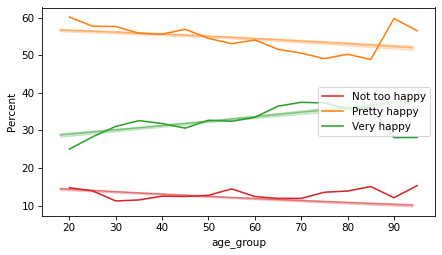

<IPython.core.display.Javascript object>

In [287]:
age_table.plot(color=colors)

for k, name in happy_map.items():
    mean_prob = predicted_probs[:, :, k].mean(axis=0)
    hdi_low, hdi_high = np.percentile(predicted_probs[:, :, k], [5, 95], axis=0)

    plt.plot(age_range, mean_prob, color=colors[k], alpha=0.5)
    plt.fill_between(age_range, hdi_low, hdi_high, color=colors[k], alpha=0.2)

decorate(ylabel="Percent")

## Adding a second predictor

In [250]:
data = gss.dropna(subset=["y", "age", "cohort"])
data.shape

(66958, 63)

<IPython.core.display.Javascript object>

In [252]:
y = data["y"].values
age = data["age"].values
cohort = data["cohort"].values

# Center age
age_shift = age.mean()
age_centered = age - age_shift

# Center cohort
cohort_shift = cohort.mean()
cohort_centered = cohort - cohort_shift

<IPython.core.display.Javascript object>

In [253]:
with pm.Model() as ordinal_model2:
    # Priors for cutpoints (thresholds)
    cutpoints = pm.Normal(
        "cutpoints",
        mu=np.array([-2, 0.6]),
        sigma=0.5,
        shape=2,
        transform=pm.distributions.transforms.ordered,
    )

    # Slopes for age and cohort
    beta_age = pm.Normal("beta_age", 0, 0.1)
    beta_cohort = pm.Normal("beta_cohort", 0, 0.1)

    # Linear predictor (age effect + cohort effect)
    eta = beta_age * age_centered + beta_cohort * cohort_centered

    # Ordinal likelihood
    y_obs = pm.OrderedLogistic(
        "y_obs", eta=eta, cutpoints=cutpoints, compute_p=False, observed=y
    )

<IPython.core.display.Javascript object>

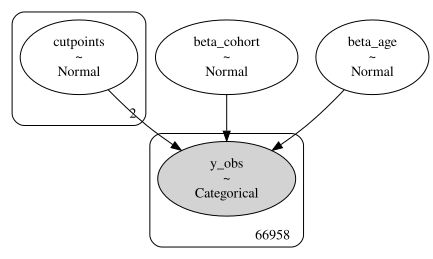

<IPython.core.display.Javascript object>

In [254]:
az.model_to_graphviz(ordinal_model2)

In [255]:
with ordinal_model2:
    idata2 = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta_age, beta_cohort]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 300 seconds.


<IPython.core.display.Javascript object>

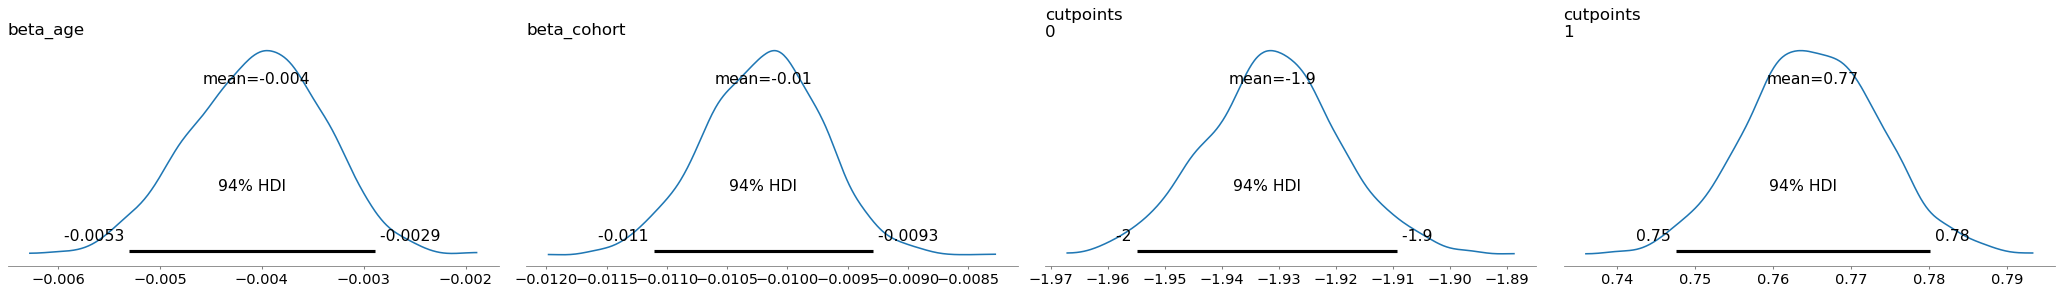

<IPython.core.display.Javascript object>

In [256]:
az.plot_posterior(idata2)
decorate()

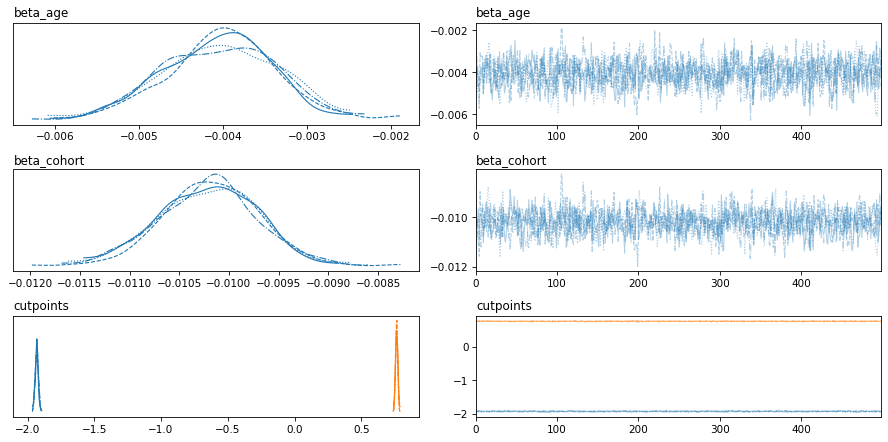

<IPython.core.display.Javascript object>

In [257]:
az.plot_trace(idata2)
decorate()

In [258]:
az.summary(idata2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_age,-0.004,0.001,-0.005,-0.003,0.0,0.0,1142.0,1083.0,1.0
beta_cohort,-0.010,0.000,-0.011,-0.009,0.0,0.0,1185.0,1343.0,1.0
cutpoints[0],-1.931,0.012,-1.955,-1.909,0.0,0.0,1157.0,953.0,1.0
cutpoints[1],0.765,0.009,0.748,0.780,0.0,0.0,3381.0,1647.0,1.0


<IPython.core.display.Javascript object>

### Plotting the results

In [259]:
data["age"].mean()

44.982750380835746

<IPython.core.display.Javascript object>

In [260]:
data["cohort"].mean()

1952.1698527435108

<IPython.core.display.Javascript object>

In [261]:
cutpoints = get_sample(idata2, "cutpoints").values
beta_age = get_sample(idata2, "beta_age").values
beta_cohort = get_sample(idata2, "beta_cohort").values
beta_age.shape

(2000,)

<IPython.core.display.Javascript object>

In [262]:
from scipy.special import expit  # sigmoid


def compute_predicted_probs(
    cutpoints, beta_age, beta_cohort, age_centered, cohort_centered
):
    """Compute predicted probabilities for each age/cohort combination.

    cutpoints: array of shape (2, n_samples)
    beta_age: array of shape (n_samples,)
    beta_cohort: array of shape (n_samples,)
    age_centered: array of shape (n_ages,)
    cohort_centered: array of shape (n_cohorts,)

    Returns: array of shape (n_samples, n_ages, n_cohorts, 3)
    """
    n_samples = beta_age.shape[0]
    n_ages = len(age_centered)
    n_cohorts = len(cohort_centered)

    # Handle broadcasting: make age and cohort both 2D
    age_centered = age_centered[:, np.newaxis]  # (n_ages, 1)
    cohort_centered = cohort_centered[np.newaxis, :]  # (1, n_cohorts)

    # Initialize output array: (n_samples, n_ages, n_cohorts, 3)
    predicted_probs = np.zeros((n_samples, n_ages, n_cohorts, 3))

    for i in range(n_samples):
        slope_age = beta_age[i]
        slope_cohort = beta_cohort[i]

        # Linear predictor for each age/cohort pair (broadcasting handles the outer product)
        eta = (
            slope_age * age_centered + slope_cohort * cohort_centered
        )  # (n_ages, n_cohorts)

        # Logits (cutpoints minus eta)
        logits = np.stack(
            [cutpoints[0, i] - eta, cutpoints[1, i] - eta], axis=-1
        )  # (n_ages, n_cohorts, 2)

        # Cumulative probabilities
        cdf_0 = expit(logits[..., 0])
        cdf_1 = expit(logits[..., 1])

        # Category probabilities
        p0 = cdf_0
        p1 = cdf_1 - cdf_0
        p2 = 1 - cdf_1

        predicted_probs[i] = np.stack([p0, p1, p2], axis=-1) * 100

    return predicted_probs

<IPython.core.display.Javascript object>

In [281]:
from scipy.special import expit  # sigmoid

# Center the age range
age_range = np.arange(18, 95)
age_centered = age_range - age_shift

# Fixed cohort value
cohort_fixed = np.array([1960])
cohort_centered = cohort_fixed - cohort_shift

n_samples = beta_age.shape[0]
n_ages = len(age_range)

predicted_probs = compute_predicted_probs(
    cutpoints, beta_age, beta_cohort, age_centered, cohort_centered
)

<IPython.core.display.Javascript object>

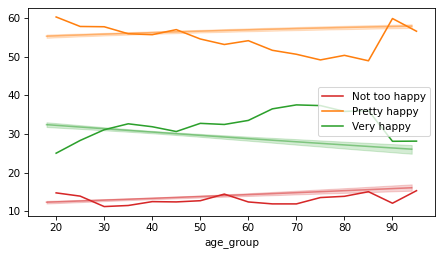

<IPython.core.display.Javascript object>

In [282]:
age_table.plot(color=colors)

for k in range(3):
    prob = predicted_probs[:, :, 0, k]
    mean_prob = prob.mean(axis=0)
    hdi_low, hdi_high = np.percentile(prob, [5, 95], axis=0)

    plt.plot(age_range, mean_prob, color=colors[k], alpha=0.5)
    plt.fill_between(age_range, hdi_low, hdi_high, color=colors[k], alpha=0.2)

decorate()

In [283]:
# Center the age range
age_fixed = np.array([40])
age_centered = age_fixed - age_shift

# Fixed cohort value
cohort_range = np.arange(1905, 2010)
cohort_centered = cohort_range - cohort_shift

n_samples = beta_age.shape[0]
n_ages = len(age_range)

predicted_probs = compute_predicted_probs(
    cutpoints, beta_age, beta_cohort, age_centered, cohort_centered
)

<IPython.core.display.Javascript object>

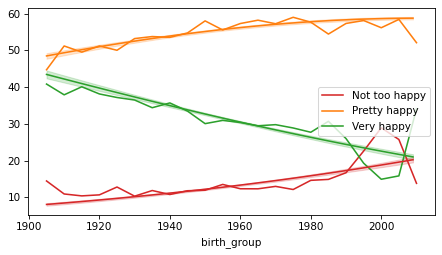

<IPython.core.display.Javascript object>

In [284]:
cohort_table.plot(color=colors)

# Squeeze out the age dimension (since age is fixed at 40)
predicted_probs_for_fixed_age = predicted_probs[
    :, 0, :, :
]  # shape (n_samples, n_cohorts, 3)

for k, name in happy_map.items():
    prob = predicted_probs[:, 0, :, k]
    mean_prob = prob.mean(axis=0)
    hdi_low, hdi_high = np.percentile(prob, [5, 95], axis=0)

    plt.plot(cohort_range, mean_prob, color=colors[k])
    plt.fill_between(cohort_range, hdi_low, hdi_high, color=colors[k], alpha=0.2)

decorate()